In [1]:
import pandas as pd
import numpy as np

In [2]:
# Carrega a planilha (sheet_name=1 equivale à segunda aba)
df = pd.read_excel("../Datos_Anonimo_20232_v2.xlsx", sheet_name=1)
df2 = pd.read_excel("../Datos_Anonimo_20231_v2.xlsx", sheet_name=1)

In [3]:
# Filtra alunos que não fizeram nenhum quiz no primeiro semestre 
faltantes2 = df2.filter(regex=r"^Fecha_Quiz\d+$").columns

df_clean2 = df2.dropna(subset=faltantes2, how="all")

df_clean2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 765 entries, 0 to 773
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Periodo                    765 non-null    object 
 1   Grupo                      765 non-null    int64  
 2   Horario                    765 non-null    object 
 3   Tipo_Documento             765 non-null    object 
 4   Edad                       765 non-null    object 
 5   Genero                     765 non-null    object 
 6   Nombre_Programa_Academico  765 non-null    object 
 7   STEM                       765 non-null    object 
 8   Parcial_1                  765 non-null    float64
 9   Parcial_2                  765 non-null    float64
 10  Proyecto_Parte1            765 non-null    float64
 11  Proyecto_Parte2            765 non-null    float64
 12  Talleres                   765 non-null    float64
 13  Quices                     765 non-null    float64
 14 

In [4]:
# Remove colunas de data de fechamento de quiz
df_clean2 = df_clean2.drop(columns=faltantes2)

df_clean2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 765 entries, 0 to 773
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Periodo                    765 non-null    object 
 1   Grupo                      765 non-null    int64  
 2   Horario                    765 non-null    object 
 3   Tipo_Documento             765 non-null    object 
 4   Edad                       765 non-null    object 
 5   Genero                     765 non-null    object 
 6   Nombre_Programa_Academico  765 non-null    object 
 7   STEM                       765 non-null    object 
 8   Parcial_1                  765 non-null    float64
 9   Parcial_2                  765 non-null    float64
 10  Proyecto_Parte1            765 non-null    float64
 11  Proyecto_Parte2            765 non-null    float64
 12  Talleres                   765 non-null    float64
 13  Quices                     765 non-null    float64
 14 

In [5]:
# Filtra os alunos que não realizaram nenhum quiz no segundo semestre
faltantes = df.filter(regex=r"^Fecha_Quiz\d+$").columns

df_clean = df.dropna(subset=faltantes, how="all")

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 611 entries, 3 to 622
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Periodo                    611 non-null    object 
 1   Grupo                      611 non-null    int64  
 2   Horario                    611 non-null    object 
 3   Tipo_Documento             611 non-null    object 
 4   Edad                       610 non-null    object 
 5   Genero                     611 non-null    object 
 6   Nombre_Programa_Academico  611 non-null    object 
 7   STEM                       610 non-null    object 
 8   Parcial_1                  611 non-null    float64
 9   Parcial_2                  611 non-null    float64
 10  Proyecto_Parte1            611 non-null    float64
 11  Proyecto_Parte2            611 non-null    float64
 12  Talleres                   611 non-null    float64
 13  Quices                     611 non-null    float64
 14 

In [6]:
# Remove colunas de data de fechamento do quiz
df_clean = df_clean.drop(columns=faltantes)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 611 entries, 3 to 622
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Periodo                    611 non-null    object 
 1   Grupo                      611 non-null    int64  
 2   Horario                    611 non-null    object 
 3   Tipo_Documento             611 non-null    object 
 4   Edad                       610 non-null    object 
 5   Genero                     611 non-null    object 
 6   Nombre_Programa_Academico  611 non-null    object 
 7   STEM                       610 non-null    object 
 8   Parcial_1                  611 non-null    float64
 9   Parcial_2                  611 non-null    float64
 10  Proyecto_Parte1            611 non-null    float64
 11  Proyecto_Parte2            611 non-null    float64
 12  Talleres                   611 non-null    float64
 13  Quices                     611 non-null    float64
 14 

In [7]:
df_concat_presentes = pd.concat([df_clean, df_clean2], ignore_index=True)

In [8]:
from sklearn.preprocessing import OneHotEncoder

In [9]:
df_categorical = df.copy()
df_categorical2 = df2.copy()

In [10]:
cat_cols = ['Tipo_Documento', 'Edad', 'Genero', 'STEM', 'MejoraNotaQuices', 'Aprobo']
df_categorical = df_categorical[cat_cols].dropna(subset = ['STEM'])
df_categorical2 = df_categorical2[cat_cols].dropna(subset = ['STEM'])

In [11]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
# Transforma a primeira tabela
encoded = encoder.fit_transform(df_categorical[cat_cols])

# Cria DataFrame com nomes corretos
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols), index=df_categorical.index)

# Junta com o dataframe original (removendo as originais)
df_categorical = df_categorical.drop(columns=cat_cols).join(encoded_df)

In [12]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
# Transforma a segunda tabela
encoded2 = encoder.fit_transform(df_categorical2[cat_cols])

# Cria DataFrame com nomes corretos
encoded_df2 = pd.DataFrame(encoded2, columns=encoder.get_feature_names_out(cat_cols), index=df_categorical2.index)

# Junta com o dataframe original (removendo as originais)
df_categorical2 = df_categorical2.drop(columns=cat_cols).join(encoded_df2)

In [13]:
df_new_categorical = pd.concat([df_categorical, df_categorical2])

# Criação de boxplot das variáveis númericas

Separação de um dataframe somente com as variáveis númericas

In [14]:
import seaborn as sns 
import matplotlib.pyplot as plt

In [15]:
# DataFrame do primeiro semestre
df_numeric = df_clean.select_dtypes(include=["number"])
df_numeric = df_numeric.drop(columns = ["Grupo"])

# DataFrame do segundo semestre
df2_numeric = df_clean2.select_dtypes(include=["number"])
df2_numeric = df2_numeric.drop(columns = ["Grupo"])

## Boxplot das variáveis númericas

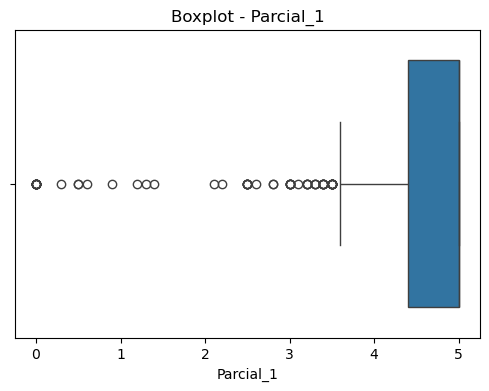

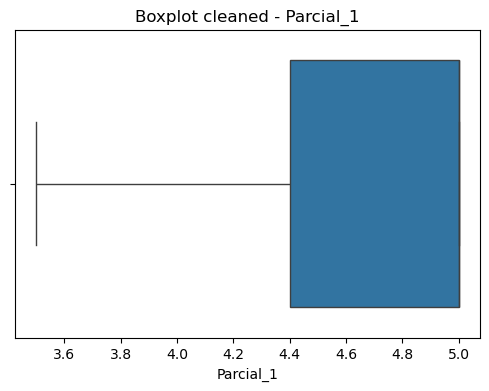

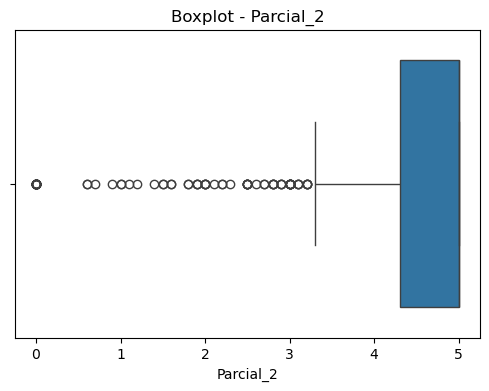

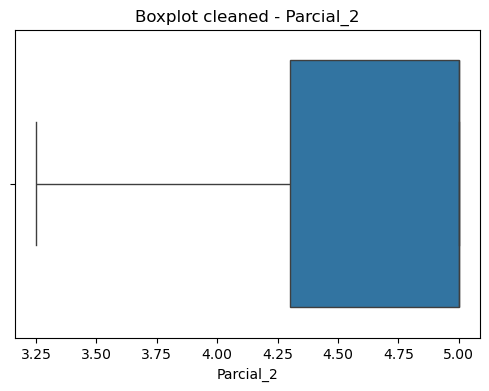

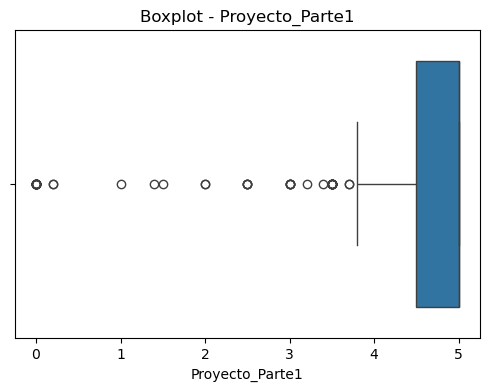

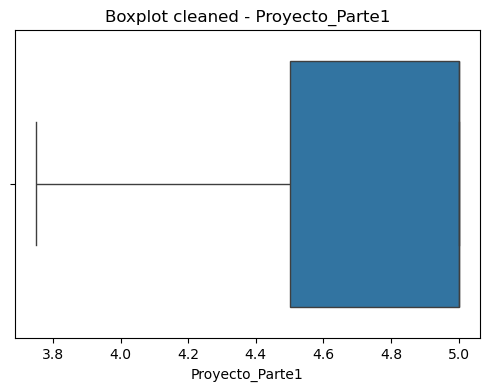

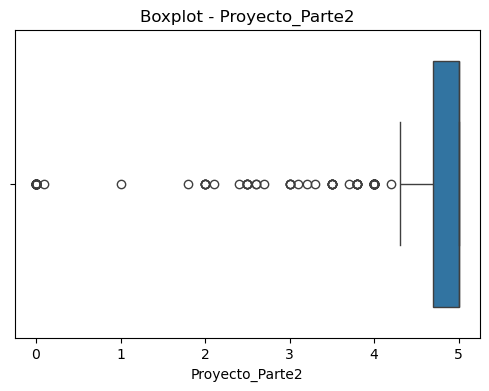

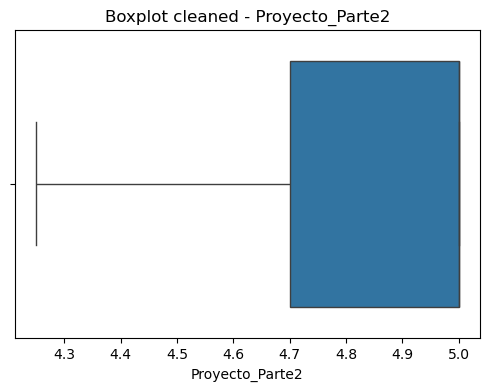

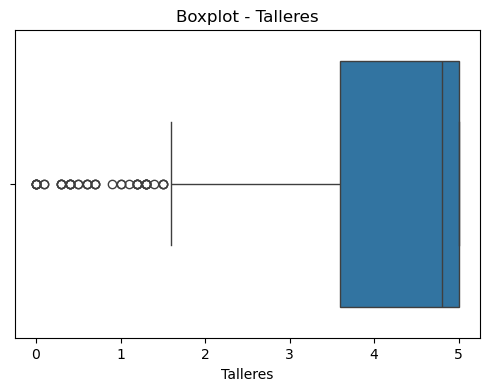

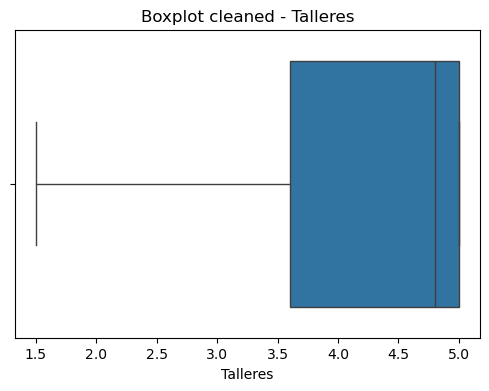

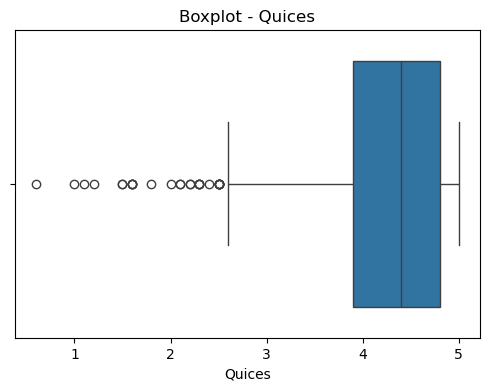

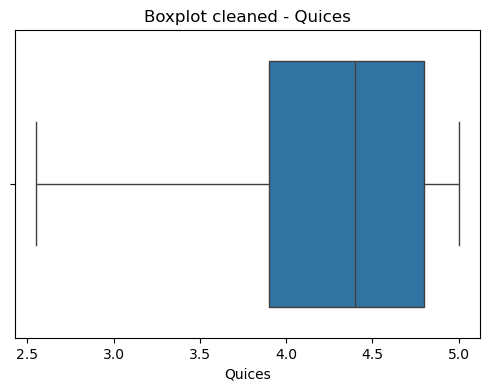

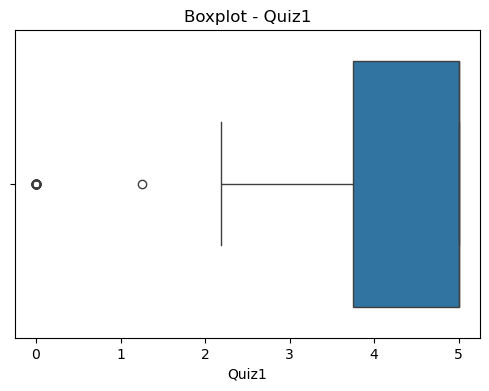

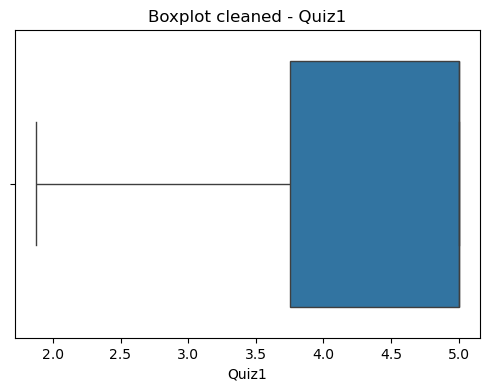

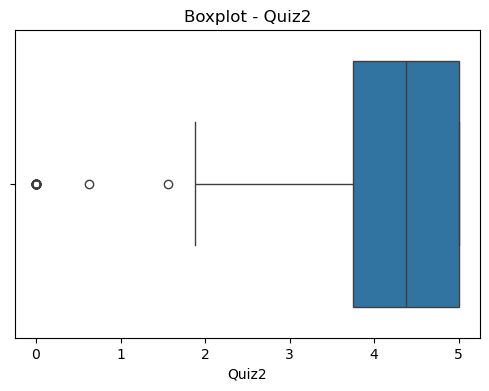

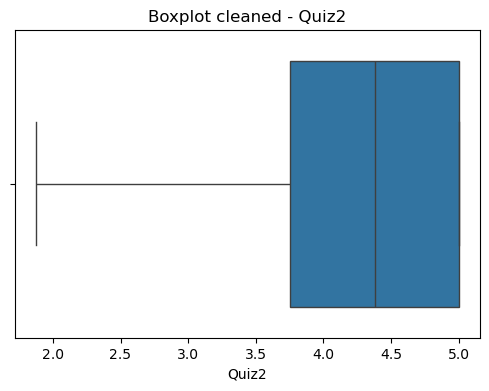

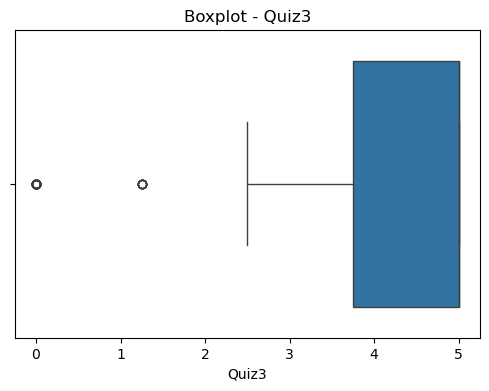

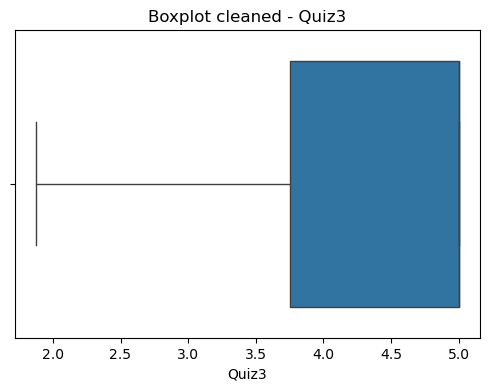

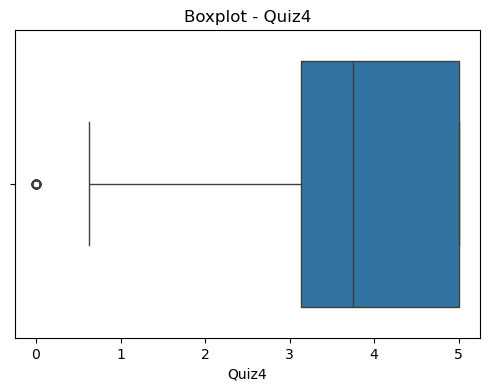

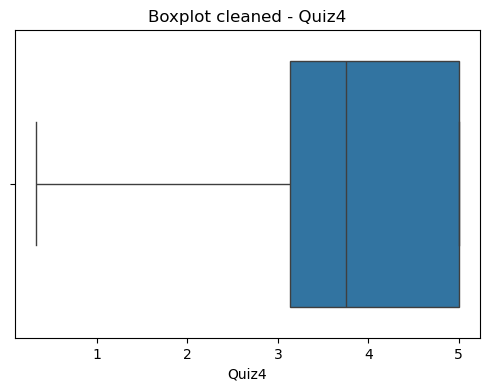

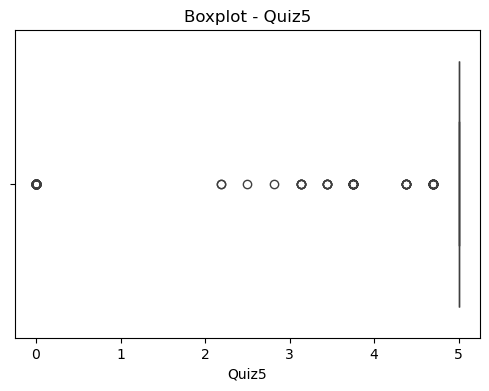

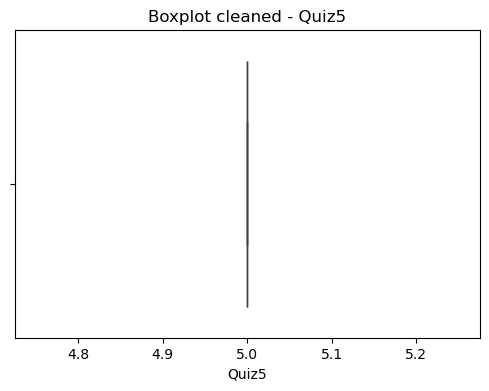

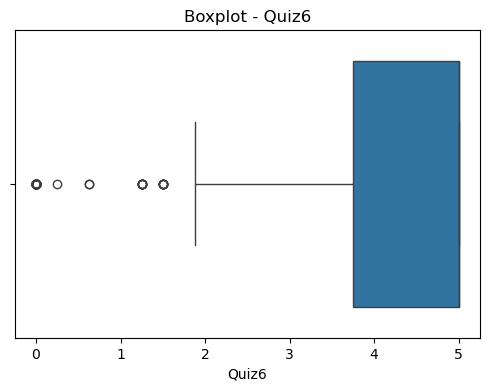

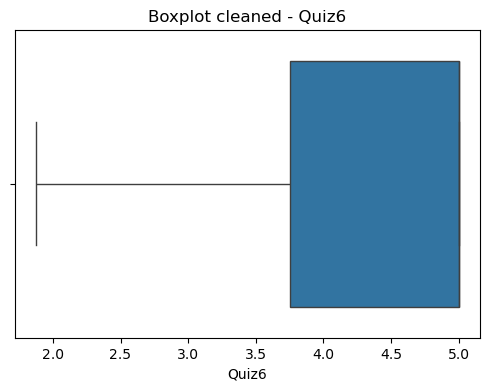

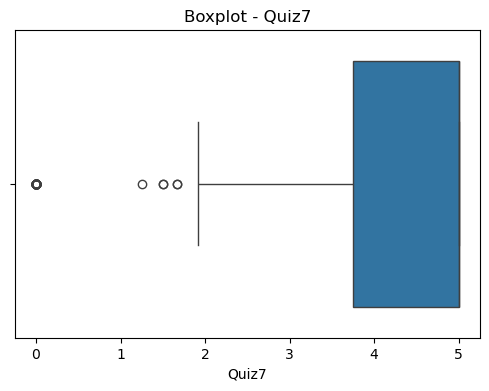

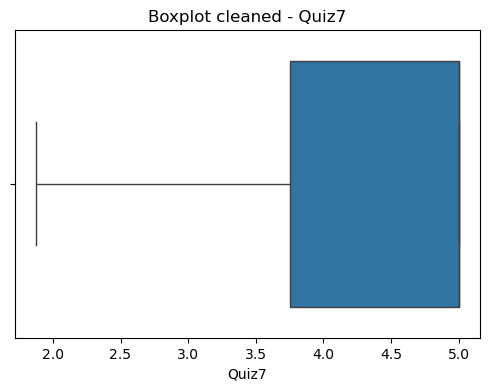

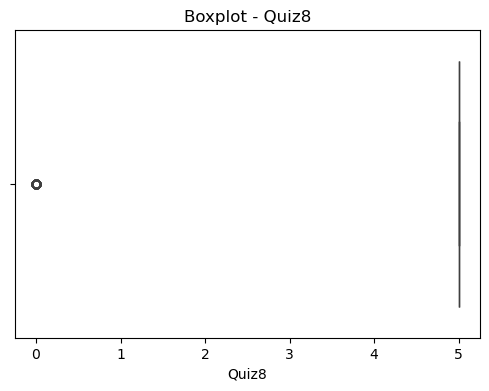

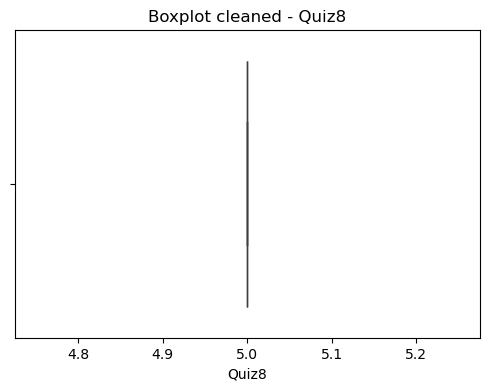

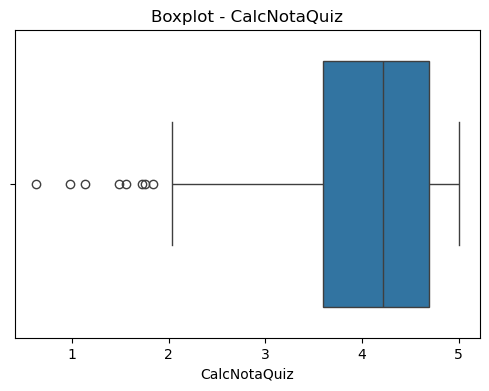

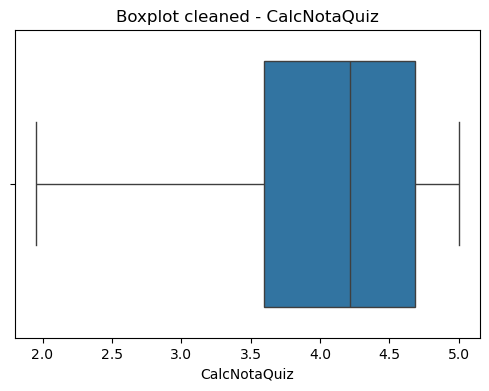

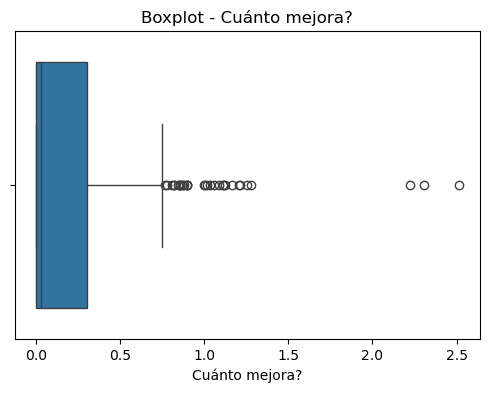

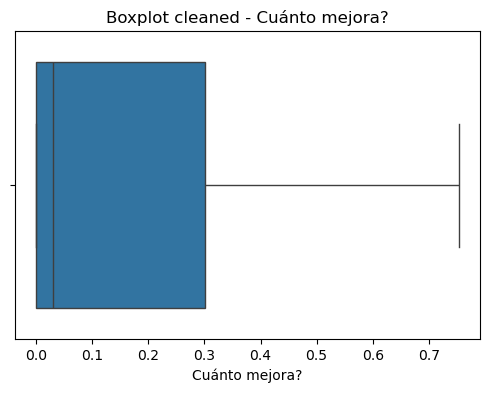

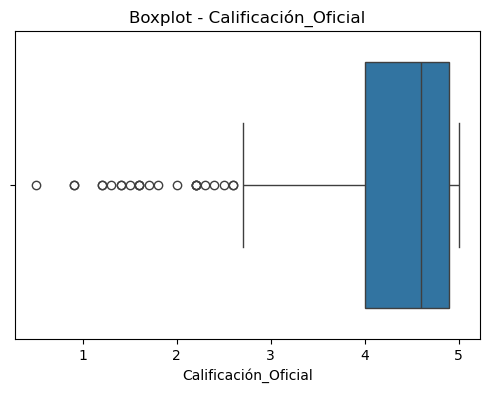

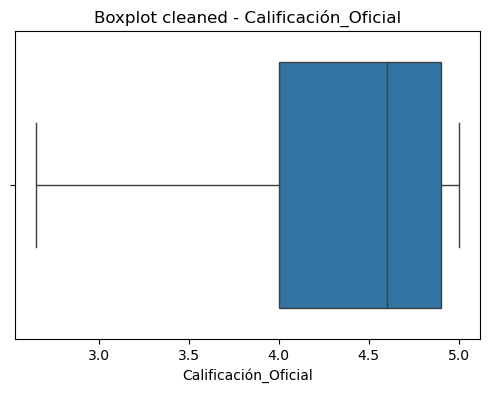

In [18]:
# Visualizar o boxplot de cada uma das variáveis númericas antes e depois do tratamento de outliers para o dataframe do primeiro semestre

df_numeric_cleaned = df_numeric.copy()

for col in df_numeric_cleaned.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_numeric_cleaned[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

    # Normalizar os outliers
    df_numeric_cleaned[col] = df_numeric_cleaned[col].clip(0, 5)
    Q1 = df_numeric_cleaned[col].quantile(0.25)
    Q3 = df_numeric_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_numeric_cleaned[col] = df_numeric_cleaned[col].clip(lower, upper)
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_numeric_cleaned[col])
    plt.title(f"Boxplot cleaned - {col}")
    plt.show()


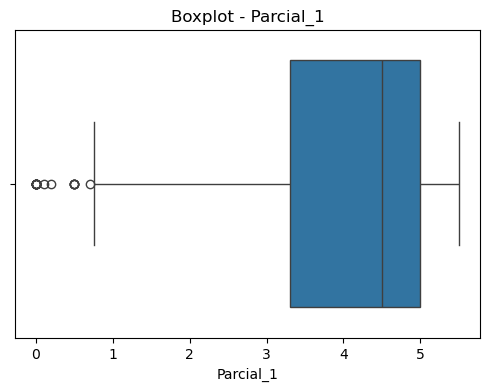

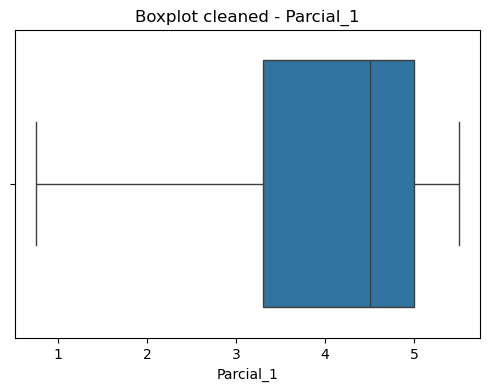

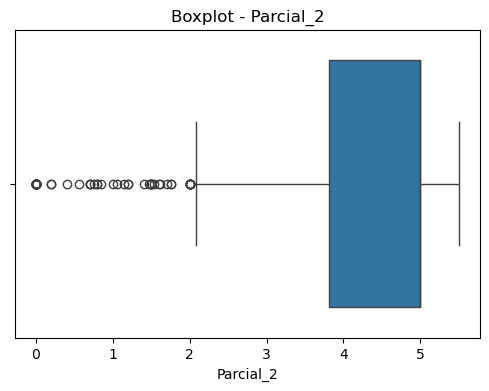

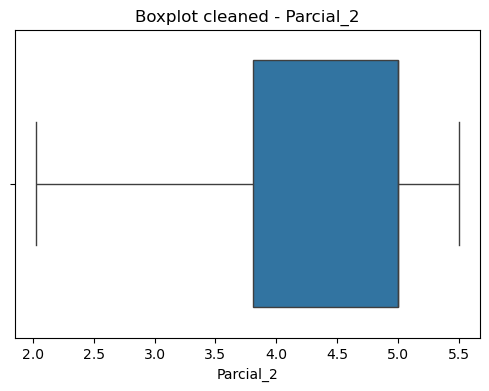

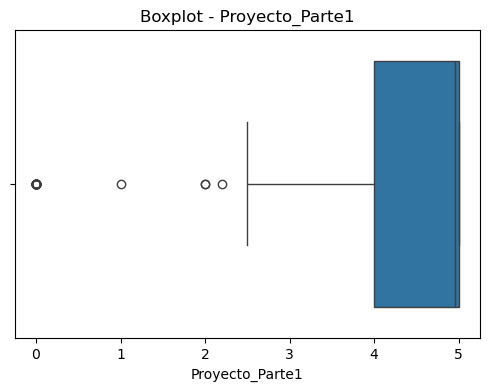

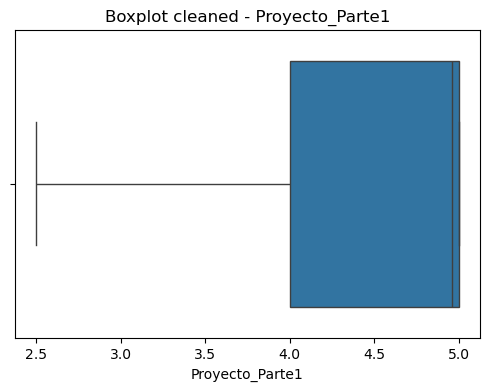

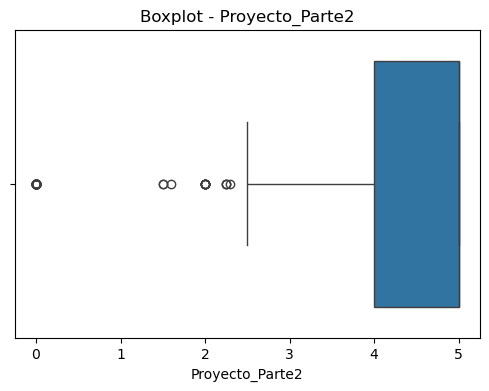

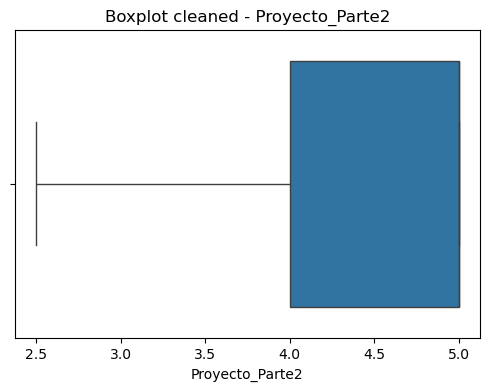

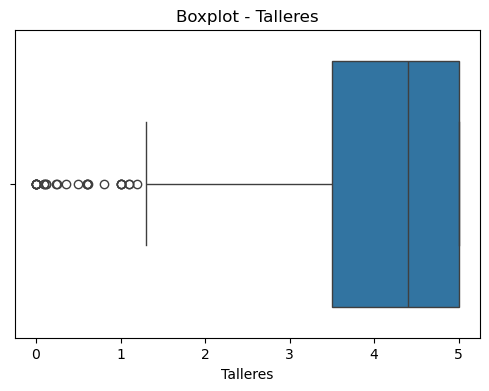

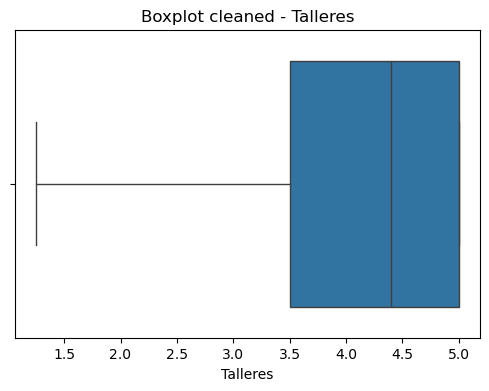

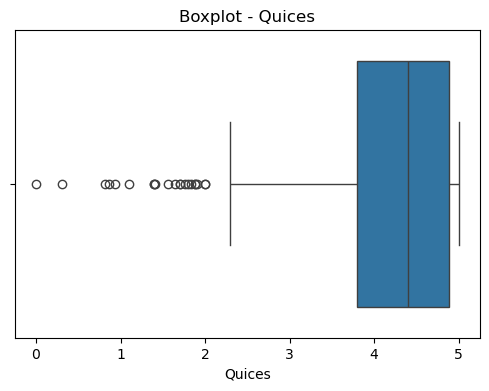

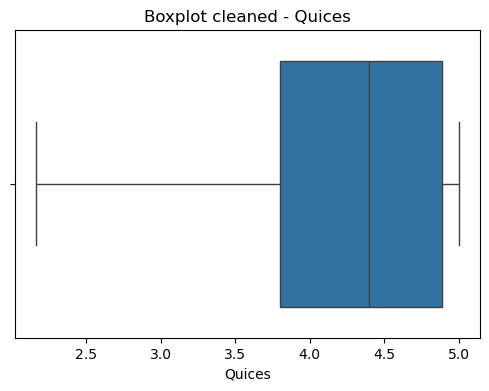

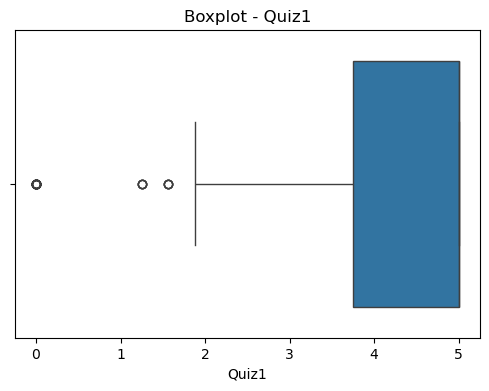

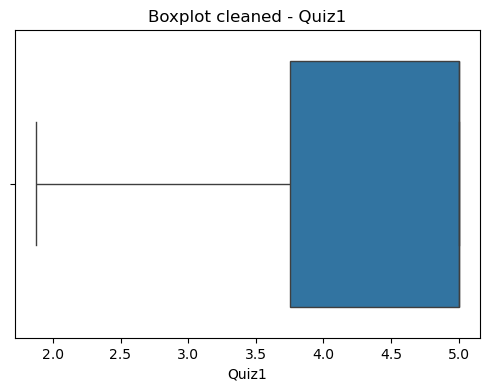

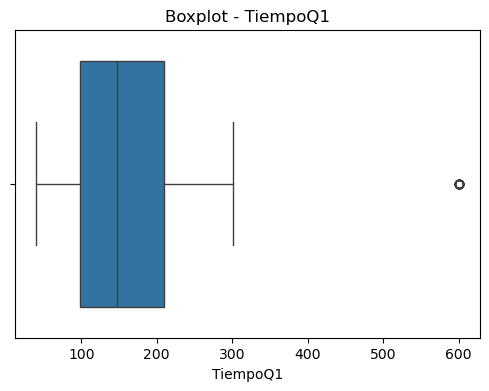

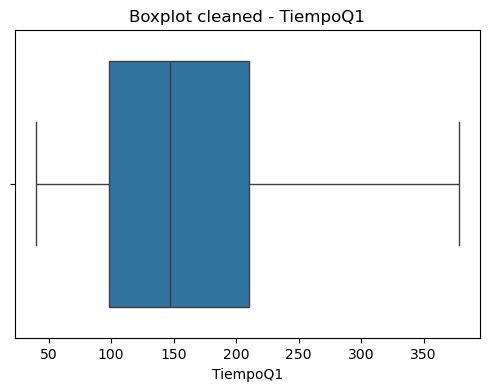

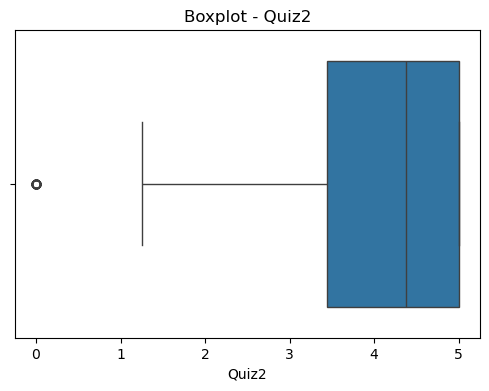

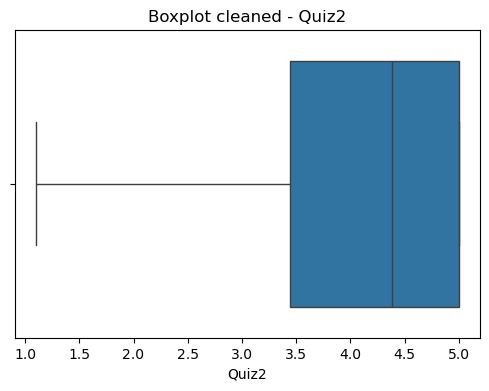

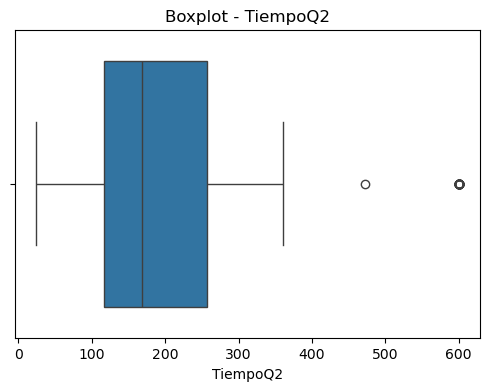

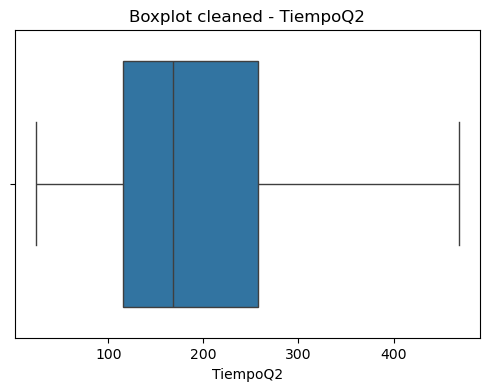

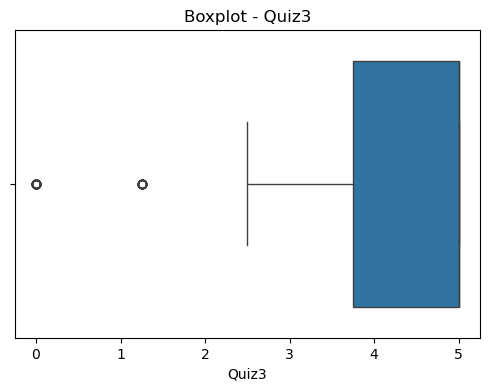

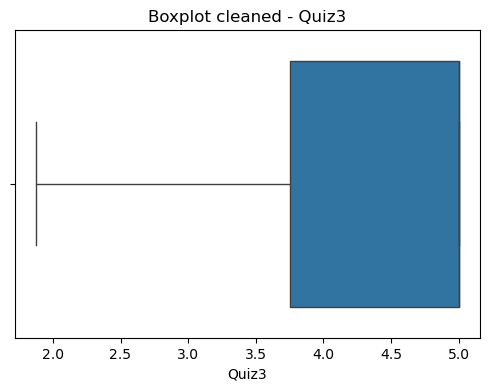

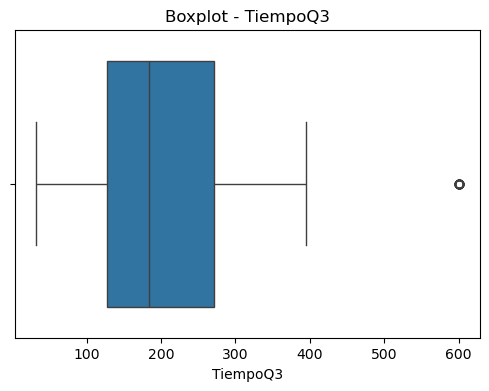

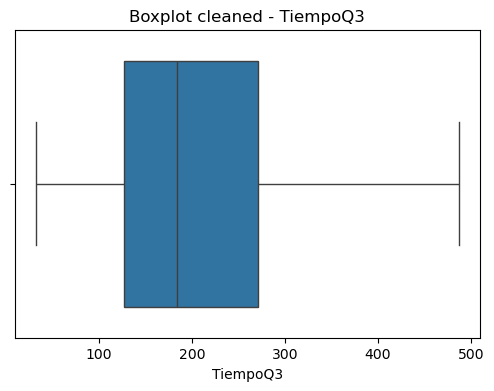

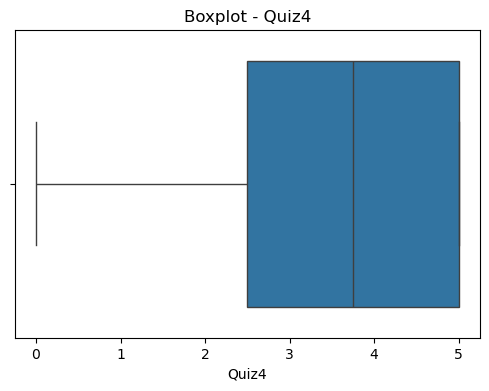

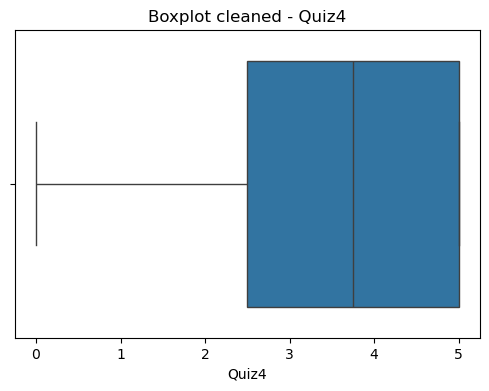

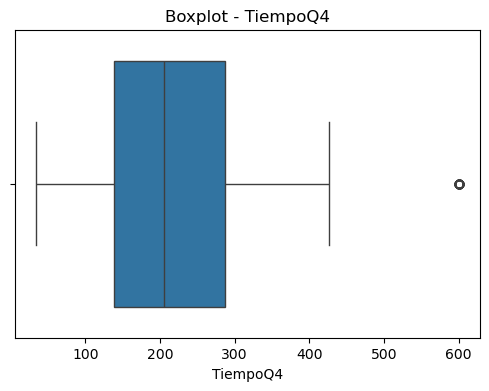

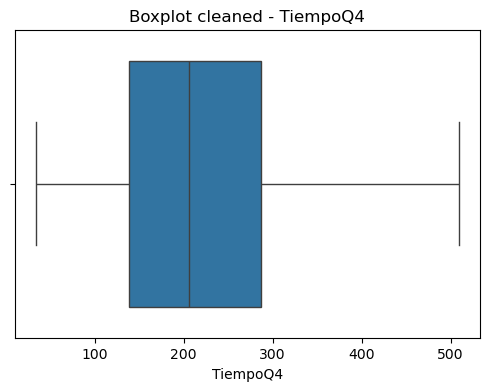

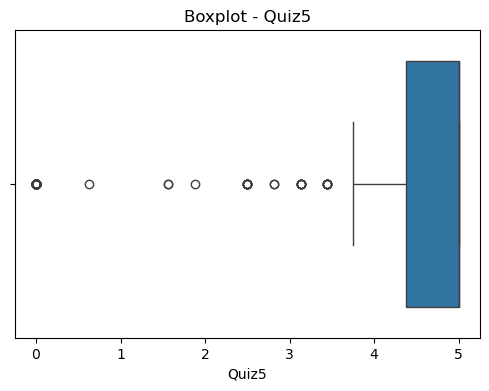

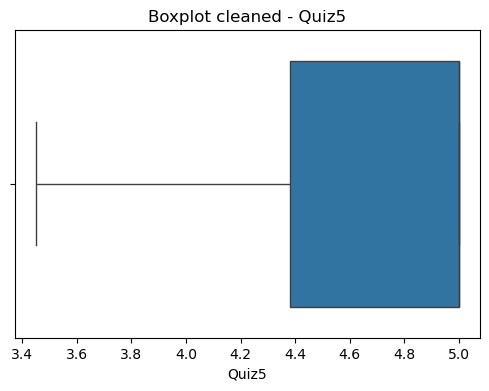

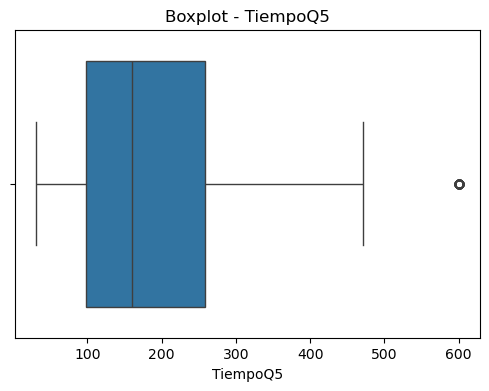

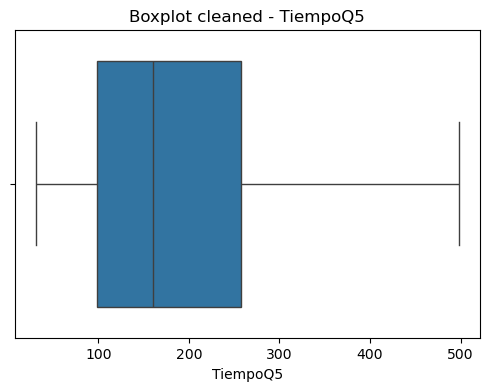

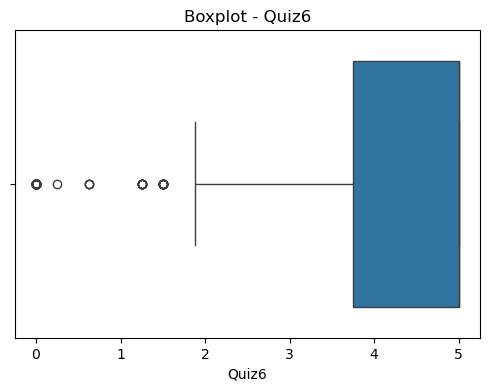

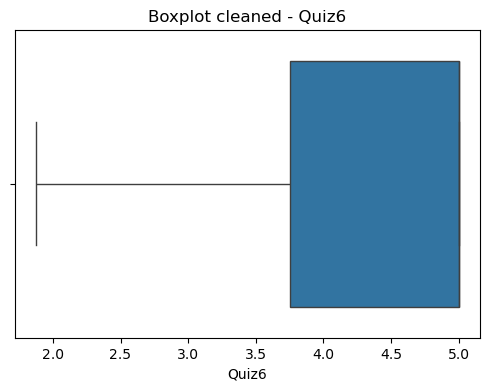

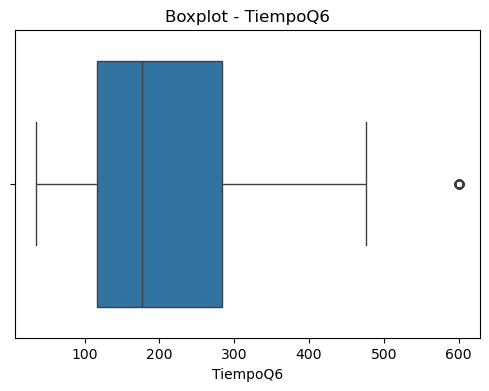

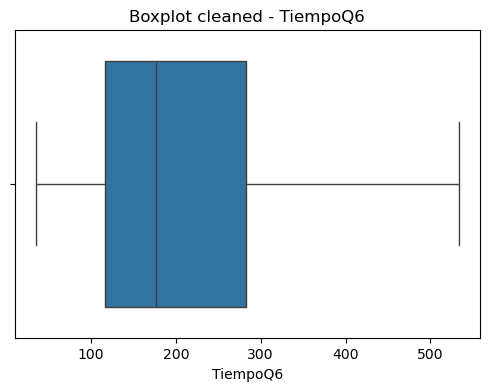

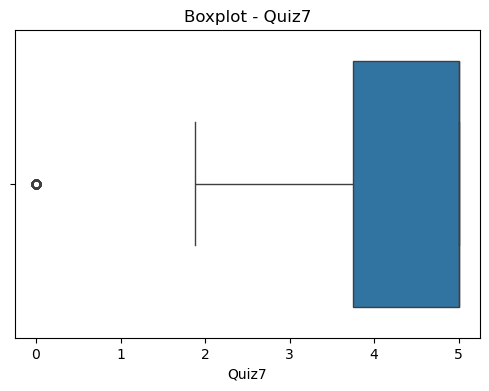

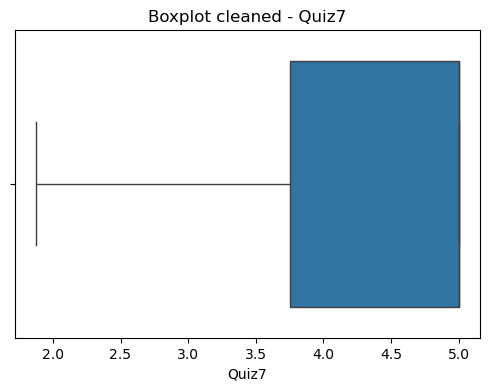

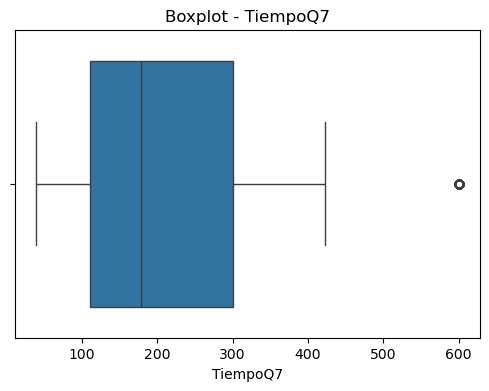

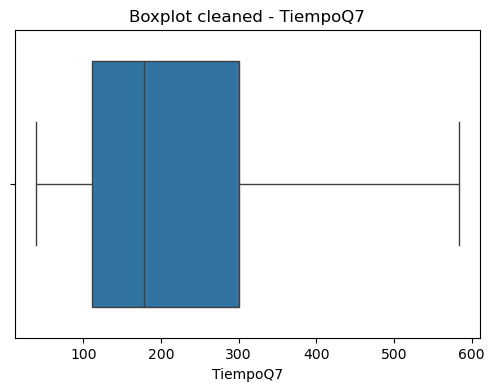

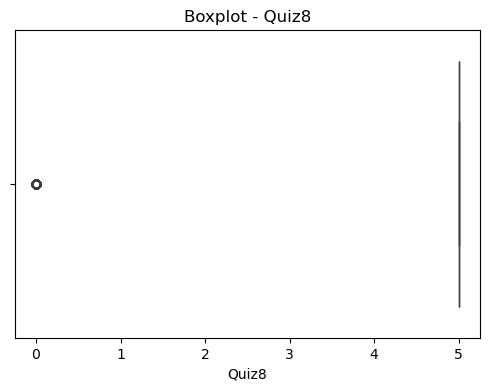

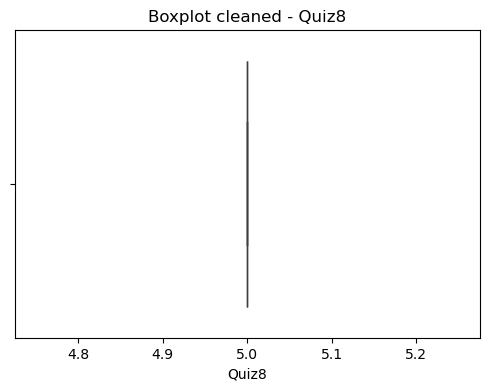

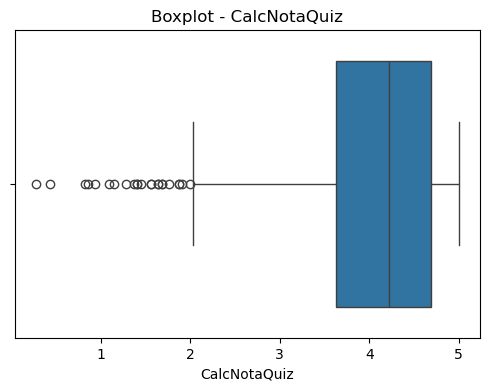

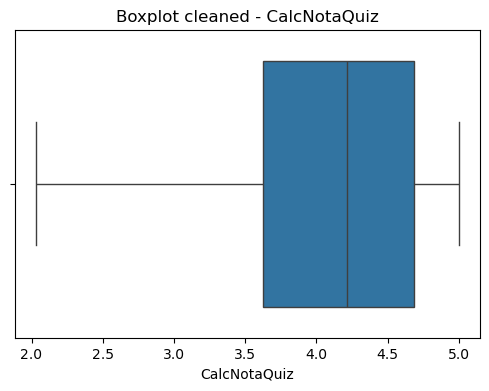

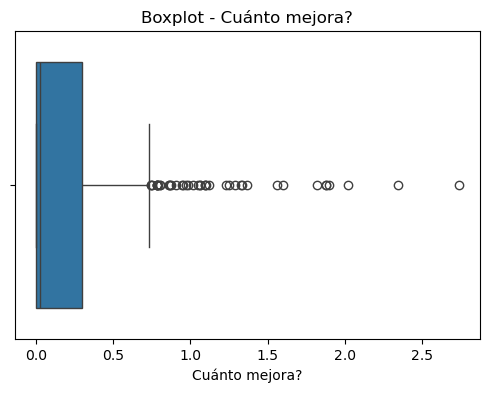

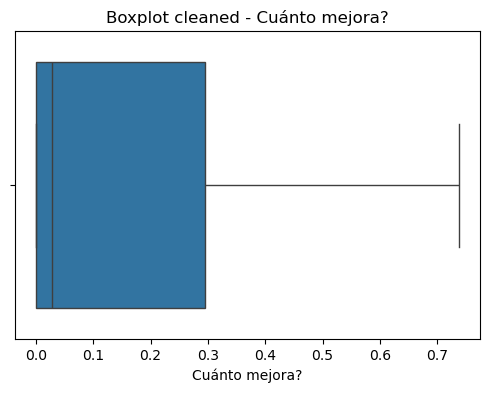

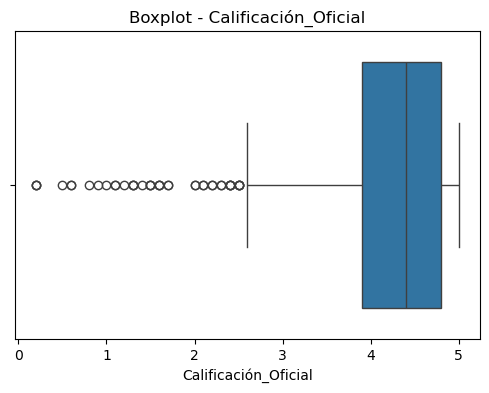

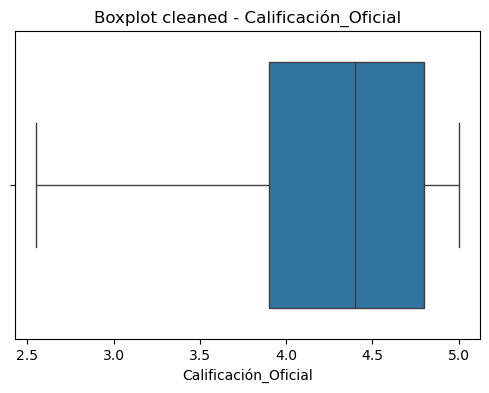

In [17]:
# Visualizar o boxplot de cada uma das variáveis númericas antes e depois do tratamento de outliers para o dataframe do primeiro semestre

df2_numeric_cleaned = df2_numeric.copy()

for col in df2_numeric_cleaned.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df2_numeric_cleaned[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

    # Normalizar os outliers
    Q1 = df2_numeric_cleaned[col].quantile(0.25)
    Q3 = df2_numeric_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df2_numeric_cleaned[col] = df2_numeric_cleaned[col].clip(lower, upper)
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df2_numeric_cleaned[col])
    plt.title(f"Boxplot cleaned - {col}")
    plt.show()
